In [2]:
import sys, os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scienceplots
plt.style.use(['science', 'no-latex'])
import tol_colors as tc
from scipy import stats

from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, fowlkes_mallows_score

from csc import *
from exp_utils import *

current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
from src import (
    TextPassages, 
    get_num_semantic_sets,
    invert_semantic_ids,
    get_pairwise_agreement,
)

In [3]:
known_duplicate_questions = [14, 83, 121]
max_annotated_question_id = 134

In [4]:
fname = f'{parent_dir}/experiments/data/working/potato_responses_gpt-4o-mini.json'
with open(fname) as f:
    potato_summary = json.load(f)

In [5]:
potato_summary_old = potato_summary.copy()

### Create files for human annotation

In [19]:
potato = read_potato_questions()
model_name = CFG["OAI"]["oai_llm_small"]
model = models.OAILLM(model=model_name)
fname = 'data/potato_responses_%s.json'%model_name
potato_human_dir = 'data/potato_human'

In [9]:
with open(fname) as f:
    potato_responses = json.load(f)

In [25]:
for i in range(11, max([int(i) for i in potato_responses.keys()])+1):
    responses = potato_responses[str(i)]["responses"]
    lines = []
    for j in range(len(responses)):
        line = f"{i} {j} {responses[j]}"
        lines.append(line)
    with open('%s/potato_human%d.txt'%(potato_human_dir, i), 'w') as f:
        for line in lines:
            f.write(f"{line}\n")

### Gather all the human annotations

In [127]:
fname = 'data/working/potato_responses_gpt-4o-mini.json'
with open(fname) as f:
    potato_summary = json.load(f)

In [136]:
for question_id in range(50, max_annotated_question_id+1):
    if question_id in known_duplicate_questions:
        continue
    with open("data/potato_human/potato_human%s.txt"%question_id) as f:
        responses = f.readlines()
    idx = 0
    cluster_ids = [0]*100
    if question_id in [60, 106]:
        potato_summary[str(question_id)]["cluster_ids"]["human"] = cluster_ids
        continue
    for response in responses:
        if response.endswith("\n"):
            response = response[:-2]
        response_split = response.split(" ")
        if response_split[1] == "-" or response_split[1] == "":
            idx +=1
            continue
        cluster_ids[int(response_split[1])] = idx
    potato_summary[str(question_id)]["cluster_ids"]["human"] = cluster_ids

In [137]:
with open(fname, "w") as f:
    json.dump(potato_summary, f)

### Gather DBSCAN cluster IDS

In [11]:
method = "similarity_85"
responses = None

for question_id in range(134+1):
    if question_id in known_duplicate_questions:
        continue
    # if method in potato_summary[str(question_id)]["cluster_ids"]:
    #     continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="dbscan",
        clustering_threshold=0.85,
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

In [31]:
method = "similarity_90"
responses = None

for question_id in range(134+1):
    if question_id in known_duplicate_questions:
        continue
    if method in potato_summary[str(question_id)]["cluster_ids"]:
        continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="dbscan",
        clustering_threshold=0.9,
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

In [21]:
method = "similarity_925"
responses = None

for question_id in range(134+1):
    if question_id in known_duplicate_questions:
        continue
    if method in potato_summary[str(question_id)]["cluster_ids"]:
        continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="dbscan",
        clustering_threshold=0.925,
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

In [38]:
method = "similarity_95"
responses = None

for question_id in range(134+1):
    if question_id in known_duplicate_questions:
        continue
    if method in potato_summary[str(question_id)]["cluster_ids"]:
        continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="dbscan",
        clustering_threshold=0.95,
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

### Gather HDBSCAN cluster IDs

In [4]:
method = "hdbscan"
responses = None

for question_id in range(134+1):
    if question_id in known_duplicate_questions:
        continue
    if method in potato_summary[str(question_id)]["cluster_ids"]:
        continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="hdbscan",
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

### Gather LLM cluster IDs

In [ ]:
method = "llm"
responses = None

for question_id in range(0, 134+1):
    print(question_id)
    if question_id in known_duplicate_questions:
        continue
    # if method in potato_summary[str(question_id)]["cluster_ids"]:
    #     continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="llm",
        return_runtime=True
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

### Gather NLI cluster IDs

In [ ]:
method = "nli"
responses = None

for question_id in range(134+1):
    print(question_id)
    if question_id in known_duplicate_questions:
        continue
    if method in potato_summary[str(question_id)]["cluster_ids"]:
        continue
    if responses is None:
        responses = TextPassages(
            passages = potato_summary[str(question_id)]["responses"],
            question = potato_summary[str(question_id)]["query"]
        )
    else:
        responses.passages = potato_summary[str(question_id)]["responses"]
        responses.question = potato_summary[str(question_id)]["query"]
        
    cluster_ids, runtime = responses.get_cluster_ids(
        method="nli",
        return_runtime=True,
        include_question=False
    )
    potato_summary[str(question_id)]["cluster_ids"][method] = cluster_ids
    
    if "cluster_runtimes" not in potato_summary[str(question_id)]:
        potato_summary[str(question_id)]["cluster_runtimes"] = {}
    potato_summary[str(question_id)]["cluster_runtimes"][method] = runtime

with open(fname, "w") as f:
    json.dump(potato_summary, f)

In [110]:
with open(fname, "w") as f:
    json.dump(potato_summary, f)

### Evaluate the quality of clustering

In [46]:
methods_to_compare = {
    "llm": "LLM",
    "nli-batch": "NLI-NQ",
    "hdbscan": "HDBSCAN",
    "similarity_95": "DBSCAN ($\\epsilon=0.05)$", # eps is distance, so 1-similarity
    "similarity_925": "DBSCAN ($\\epsilon=0.075)$",
    "similarity_90": "DBSCAN ($\\epsilon=0.1)$",
    "similarity_85": "DBSCAN ($\\epsilon=0.15)$"
}

In [48]:
data = {m: "" for m in methods_to_compare}
data_headings = []
idx_vals = range(max_annotated_question_id+1)
for rater in methods_to_compare:
    for one_class in [False, True]:
        fmi_values = []
        nmi_values = []
        agreement_values = []
        for question_id in idx_vals:
            if question_id in known_duplicate_questions:
                continue
            human_ids = potato_summary[str(question_id)]['cluster_ids']['human']

            if not one_class and max(human_ids)==0:
                # |S|>1: EXCLUDING questions resulting in ONLY one semantic category
                continue
            if one_class and max(human_ids)>1:
                # |S|=1: EXCLUDING questions resulting in MORE THAN one semantic category
                continue
    
            if rater == "llm":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['llm']
            if rater == "nli":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['nli']
            if rater == "nli-batch":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['nli-batch']
            if rater == "hdbscan":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['hdbscan']
            if rater == "similarity_85":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['similarity_85']
            if rater == "similarity_90":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['similarity_90']
            if rater == "similarity_925":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['similarity_925']
            if rater == "similarity_95":
                predicted_labels = potato_summary[str(question_id)]['cluster_ids']['similarity_95']

            nmi = normalized_mutual_info_score(human_ids, predicted_labels)
            nmi_values.append(nmi)
            fmi = fowlkes_mallows_score(human_ids, predicted_labels)
            fmi_values.append(fmi)
            agreement = get_pairwise_agreement(
                potato_summary[str(question_id)]['responses'], 
                human_ids, 
                predicted_labels
            )
            agreement_values.append(agreement)
        
        half_row = "&  %.2f  &  %.2f &  %.2f  "%(np.mean(fmi_values), np.mean(nmi_values), np.mean(agreement_values))
        data[rater] += half_row

        if len(data_headings)<6:
            if one_class:
                data_headings += ["S=1 FMI", "S=1 NMI", "S=1 PA"]
            else:
                data_headings += ["S>1 FMI", "S>1 NMI", "S>1 PA"]

print(data_headings)
for m in data:
    row = f"  &  {methods_to_compare[m]}  {data[m]} \\\\"
    if m == "llm":
        prepend_str = "\\multirow{2}{*}{Bidirectional Entailment}"
        row = prepend_str + row
    if m == "hdbscan":
        print("\\hline")
        prepend_str = "\\multirow{5}{*}{Semantic Embedding}"
        row = prepend_str + row
    print(row)

['S>1 FMI', 'S>1 NMI', 'S>1 PA', 'S=1 FMI', 'S=1 NMI', 'S=1 PA']
\multirow{2}{*}{Bidirectional Entailment}  &  LLM  &  0.84  &  0.72 &  0.84  &  0.86  &  0.71 &  0.80   \\
  &  NLI-NQ  &  0.84  &  0.64 &  0.85  &  0.89  &  0.61 &  0.89   \\
\hline
\multirow{5}{*}{Semantic Embedding}  &  HDBSCAN  &  0.68  &  0.52 &  0.69  &  0.70  &  0.41 &  0.60   \\
  &  DBSCAN ($\epsilon=0.05)$  &  0.86  &  0.71 &  0.82  &  0.86  &  0.65 &  0.77   \\
  &  DBSCAN ($\epsilon=0.075)$  &  0.87  &  0.68 &  0.82  &  0.88  &  0.60 &  0.79   \\
  &  DBSCAN ($\epsilon=0.1)$  &  0.85  &  0.57 &  0.79  &  0.88  &  0.51 &  0.80   \\
  &  DBSCAN ($\epsilon=0.15)$  &  0.79  &  0.27 &  0.66  &  0.87  &  0.25 &  0.76   \\


### Semantic Categories Dist Plot

In [ ]:
methods_to_compare = {
    "human": "Observed",
}
large_fontsize = 20
medium_fontsize = 17.5
small_fontsize = 15

colors = tc.get_colorset('muted')
method_colors = {
    'possible': "grey",
    'human': "black",
}

In [25]:
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['text.latex.preamble'] = r'\usepackage[cm]{sfmath}'
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Helvetica:italic'
import seaborn as sns

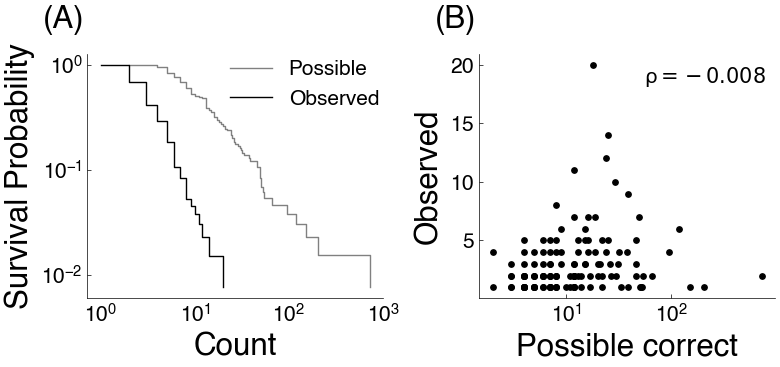

In [32]:
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

palette_idx = 0
idx_vals = range(max_annotated_question_id+1)

potato_all = read_potato_questions("data/potato_questions.txt")
possible_values = [_ for _ in potato_all.values()]
values = [
    possible_values[i] for i in idx_vals \
    if i not in known_duplicate_questions and isinstance(possible_values[i], (int, float))
]
value_counts = Counter(values)
unique_values = sorted(value_counts.keys())
total_count = sum(value_counts.values())
ccdf = [sum(value_counts[v] for v in value_counts if v >= x) / total_count for x in unique_values]
ax1.step(
    unique_values, ccdf, where='post', label="Possible", 
    color=method_colors["possible"]
)

runtime_means = []
runtime_stds = []

for method in methods_to_compare:
    palette_idx += 1
    num_cat_values = []
    runtimes = []
    for question_id in idx_vals:
        if question_id in known_duplicate_questions:
            continue
        num_categories = max(potato_summary[str(question_id)]['cluster_ids'][method])+1
        num_cat_values.append(num_categories)

        if method != "human":
            runtime = potato_summary[str(question_id)]['cluster_runtimes'][method]
            runtimes.append(runtime)

    value_counts = Counter(num_cat_values)
    unique_values = sorted(value_counts.keys())
    total_count = sum(value_counts.values())
    ccdf = [sum(value_counts[v] for v in value_counts if v >= x) / total_count for x in unique_values]
    ax1.step(
        unique_values,
        ccdf,
        where='post',
        label=methods_to_compare[method],
        color=method_colors[method]
    )
    runtime_means.append(np.mean(runtimes))
    runtime_stds.append(np.std(runtimes))

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Count', fontsize=large_fontsize)
ax1.set_ylabel('Survival Probability', fontsize=large_fontsize)
ax1.legend(loc="upper right", fontsize=medium_fontsize, bbox_to_anchor=(1.05, 1.05))
ax1.tick_params(axis='x', which='both', bottom=False, top=False)  # disable all x-axis ticks
ax1.tick_params(axis='both', which='major', labelsize=small_fontsize)
ax1.tick_params(axis="y", which="major", right=False)
ax1.text(-0.15, 1.2, 
    '(A)',
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='left', 
    fontweight='bold',
    fontsize=large_fontsize,
)
sns.despine(top=True, right=True, left=False, bottom=False, ax=ax1)
ax1.xaxis.set_minor_locator(plt.NullLocator())
ax1.yaxis.set_minor_locator(plt.NullLocator())

possible_pairs = []
human_pairs = []
for question_id in idx_vals:
    if question_id in known_duplicate_questions:
        continue
    query = potato_summary[str(question_id)]["query"]
    num_possible_categories = potato_all[query]
    if num_possible_categories == "[UNK]":
        continue
    num_human_ids = max(potato_summary[str(question_id)]["cluster_ids"]["human"]) + 1
    possible_pairs.append(num_possible_categories)
    human_pairs.append(num_human_ids)
ax2.scatter(possible_pairs, human_pairs, s=15, color=method_colors["human"])
correlation_coefficient, p_value = stats.pearsonr(possible_pairs, human_pairs)
ax2.text(55, 18.5, f'$ρ={correlation_coefficient:.3f}$', fontsize=medium_fontsize)
ax2.set_xscale("log")
ax2.set_ylabel("Observed", fontsize=large_fontsize)
ax2.set_xlabel("Possible correct", fontsize=large_fontsize)
ax2.text(-0.15, 1.2, 
    '(B)',
    transform=ax2.transAxes, 
    verticalalignment='top', 
    horizontalalignment='left', 
    fontweight='bold',
    fontsize=large_fontsize
)
ax2.tick_params(axis='both', which='major', labelsize=small_fontsize)
ax2.tick_params(axis="y", which="major", right=False)
ax2.tick_params(axis="x", which="major", top=False) 
sns.despine(top=True, right=True, left=False, bottom=False, ax=ax2)
ax2.xaxis.set_minor_locator(plt.NullLocator())
ax2.yaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.savefig('figures/potato_ccdf.eps')
plt.show()